
Task 1: Supervised Learning – Calorie Burn Prediction (Regression)



Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
Base_MET                         0
HR_Intensity                     0
Effective_MET                    0
Calories_Burned (kcal)           0
dtype: int64
Outliers detected in the following columns:
  'Weight':
95       110.5
144      106.9
172      118.1
203      106.9
295      107.8
         ...  
13355    112.3
13448    106.8
13461    108.9
13580    110.8
13600    119.0
Name: Weight, Length: 93, dtype: float64
  'Session_Duration':
30       1.69
877      1.66
900      1.90
1023     1.65
1127     1.72
123

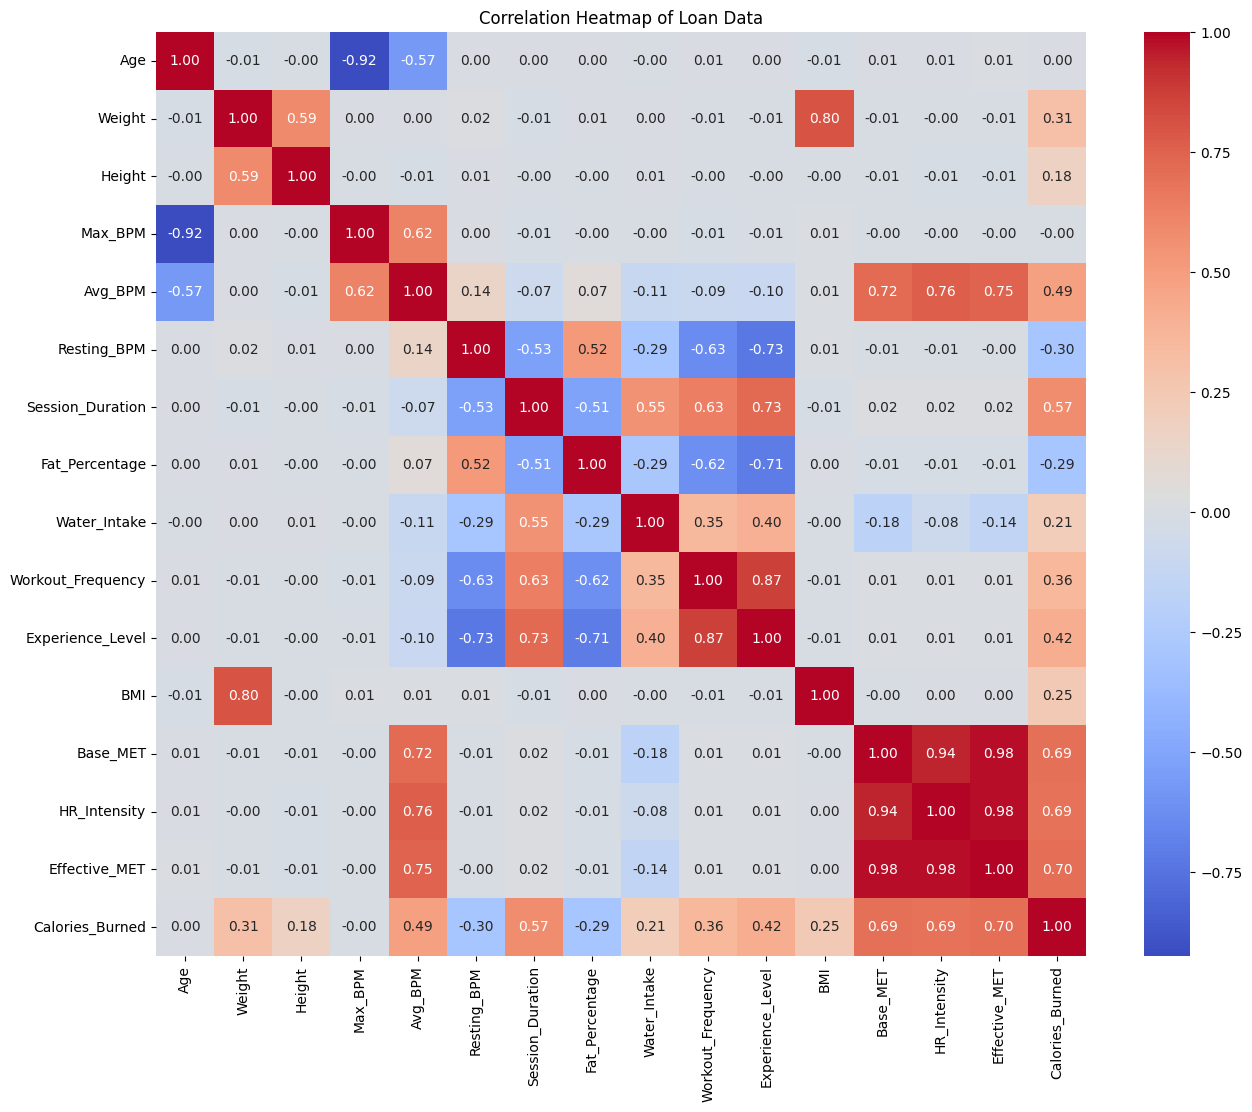

....MinMaxScaler LinearRegression Results:....
Mean Absolute Error: 34.968163760719
Root Mean Squared Error: 53.576098360842174
R-squared: 0.9085749875564642

....StandardScaler  LinearRegression Results:....
Mean Absolute Error: 34.968163760719
Root Mean Squared Error: 53.576098360842174
R-squared: 0.9085749875564642

....KNeighborsRegressor Results:....
Mean Absolute Error: 32.152619638426096
Root Mean Squared Error: 45.91537004975673
R-squared: 0.9328510788832259

....XGBoost Regressorr Results:....
Mean Squared Error: 59.31340850649762
RMSE(Root Mean Squared Error): 7.702
R²: 0.998

....Decision Tree Regressor Results:....
RMSE: 7.702
MSE: 176.759
R²: 0.994

....Random Forest Regressor Results:....
Mean Absolute Error: 3.7899475363346316
Root Mean Squared Error: 8.00911832300823
R-squared: 0.9979568874986061

....Support Vector Regression Results:....
Mean Absolute Error: 37.30236678178069
Root Mean Squared Error: 66.46279977179918
R-squared: 0.859304526329858


Text(0.5, 1.0, ' Linear Regressor Actual vs Predicted Calories')

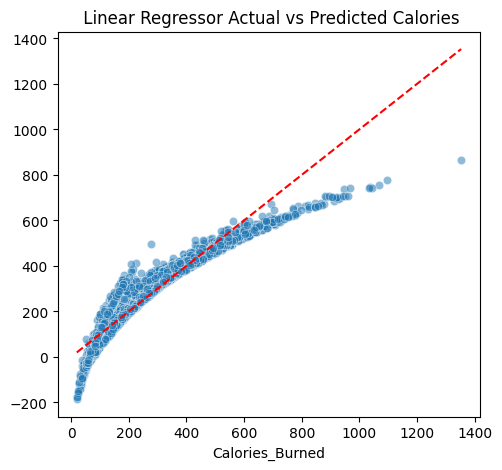

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os

# ML Imports
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn import metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score
from sklearn.decomposition import PCA

# Models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.cluster import KMeans
from sklearn.svm import SVR

# 1.data loading and cleaning:

df_raw_fit  = pd.read_csv('/content/Fitbit_dataset.csv')
#axis=0 refers to the Index (Rows). It moves vertically (up a nd down).
#axis=1 refers to the Columns. It moves horizontally (left to right).
df_raw_fit = df_raw_fit.drop(['Unnamed: 0'], axis=1)#(14102, 18)
print(df_raw_fit.isnull().sum())
df_raw_fit.shape #(14102, 19)
#df_raw.dtypes

df_raw_fit = df_raw_fit.drop_duplicates()
#df_raw = df_raw.dropna()
df_raw_fit.shape #(14102, 19)

# Strip spaces and replace special characters
df_raw_fit.columns = df_raw_fit.columns.str.replace(r' \(.*\)', '', regex=True).str.replace(' ', '_')

# Result: 'Calories_Burned (kcal)' becomes 'Calories_Burned'
df_raw_fit.head()
df_raw_cleaned = df_raw_fit.copy()

# 2.IQR #findout the outlier bounder based on target
# Select only numerical columns for outlier detection
numerical_df = df_raw_fit.select_dtypes(include=['number'])

# 3.Identify outliers using the IQR method for numerical columns
Q1 = numerical_df.quantile(0.25)
Q3 = numerical_df.quantile(0.75)
IQR = Q3 - Q1
# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = {}
for column in numerical_df.columns:
    col_outliers = numerical_df[(numerical_df[column] < lower_bound[column]) | (numerical_df[column] > upper_bound[column])]
    if not col_outliers.empty:
        outliers[column] = col_outliers[column]
if outliers:
    print("Outliers detected in the following columns:")
    for col, data in outliers.items():
        print(f"  '{col}':\n{data}")
else:
    print("No significant outliers detected using the IQR method.")

# 4. Calculate the correlation matrix for numerical columns# Plotting the heatmap
correlation_matrix = numerical_df.corr(numeric_only=True)
plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Loan Data')
plt.show()

# 5. Separate features (x) and target (y) from the encoded DataFrame

x = df_raw_cleaned.drop(columns=["Calories_Burned", "Age" ,"Max_BPM"])
y = df_raw_cleaned["Calories_Burned"]
x = pd.get_dummies(x, columns=['Gender','Workout_Type'], drop_first=True)
z = pd.concat([x,y],axis=1)
z.head()

# 6. Train-test split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

#Min Max Scaler#x_scaled = (x – x_min)/(x_max – x_min)--------
scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

model_minmax = LinearRegression()
model_minmax.fit(x_train_scaled, y_train)
y_pred_minmax = model_minmax.predict(x_test_scaled)

# Print the evaluation metrics
print("....MinMaxScaler LinearRegression Results:....")
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred_minmax))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred_minmax)))
print('R-squared:', r2_score(y_test, y_pred_minmax))

#Model 1.Standard Scaler LinearRegression----------
model_standard = LinearRegression()
model_standard.fit(x_train_scaled, y_train)
y_pred_standard = model_standard.predict(x_test_scaled)


print("\n....StandardScaler  LinearRegression Results:....")
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred_standard))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred_standard)))
print('R-squared:', r2_score(y_test, y_pred_standard))


#Model 2.Initialize KNN Regressor -------------
model_knn = KNeighborsRegressor(n_neighbors=5)
model_knn.fit(x_train_scaled, y_train)
y_pred_knn = model_knn.predict(x_test_scaled)

# Evaluate the model
print("\n....KNeighborsRegressor Results:....")
print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred_knn))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test, y_pred_knn)))
print('R-squared:', r2_score(y_test, y_pred_knn))

#Model 3.XGBoost Regressor-----------------
model_xgboost = XGBRegressor(objective='reg:squarederror',n_estimators=100, random_state=42)
model_xgboost.fit(x_train_scaled, y_train)
y_pred_xgboost = model_xgboost.predict(x_test_scaled )

rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgboost))
r2 = r2_score(y_test, y_pred_xgboost)

print("\n....XGBoost Regressorr Results:....")
print('Mean Squared Error:', mean_squared_error(y_test, y_pred_xgboost))
print(f'RMSE(Root Mean Squared Error): {rmse:.3f}')
print(f'R²: {r2:.3f}')

#Model 4.Decision Tree Regressor-------------------
model_regress = DecisionTreeRegressor(random_state=42)
model_regress.fit(x_train_scaled,y_train)
y_pred_regress = model_regress.predict(x_test_scaled)

mse = mean_squared_error(y_test, y_pred_regress)
r2 = r2_score(y_test, y_pred_regress)

print("\n....Decision Tree Regressor Results:....")
print(f'RMSE: {rmse:.3f}')
print(f'MSE: {mse:.3f}')
print(f'R²: {r2:.3f}')

#Model 5.Random Forest Regressor------------------------
model_rft = RandomForestRegressor()
model_rft.fit(x_train_scaled,y_train)
y_pred_rft = model_rft.predict(x_test_scaled)

# Evaluate the model
print("\n....Random Forest Regressor Results:....")
print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred_rft))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test, y_pred_rft)))
print('R-squared:', r2_score(y_test, y_pred_rft))

#Model 6.Support Vector Regression---------------------
model_svr = SVR()
model_svr.fit(x_train_scaled,y_train)
y_pred_svr = model_svr.predict(x_test_scaled)

# Evaluate the model
print("\n....Support Vector Regression Results:....")
print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred_svr))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test, y_pred_svr)))
print('R-squared:', r2_score(y_test, y_pred_svr))

# Regression Performance
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_standard, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.title(" Linear Regressor Actual vs Predicted Calories")


In [ ]:
# Trunning performance for knn GridSearchCV

from sklearn.model_selection import GridSearchCV

# Define the parameter grid for KNN
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Initialize GridSearchCV
# Using x_train_scaled and y_train for tuning
grid_search_knn = GridSearchCV(
    KNeighborsRegressor(),
    param_grid,
    cv=5, # 5-fold cross-validation
    scoring='r2', # Use R-squared for scoring
    n_jobs=-1, # Use all available cores
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search_knn.fit(x_train_scaled, y_train)

# Get the best parameters and best score
print("\nBest parameters for KNN:", grid_search_knn.best_params_)
print("Best R-squared score on training data (cross-validation):", grid_search_knn.best_score_)

# Evaluate the best KNN model on the test data
y_pred_knn_tuned = grid_search_knn.best_estimator_.predict(x_test_scaled)

print("\n....Tuned KNeighborsRegressor Results:....")
print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred_knn_tuned))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test, y_pred_knn_tuned)))
print('R-squared:', r2_score(y_test, y_pred_knn_tuned))


Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best parameters for KNN: {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'distance'}
Best R-squared score on training data (cross-validation): 0.9341017352698762

....Tuned KNeighborsRegressor Results:....
Mean Absolute Error: 31.231856906847703
Root Mean Squared Error: 45.08978101497335
R-squared: 0.9352441342826432


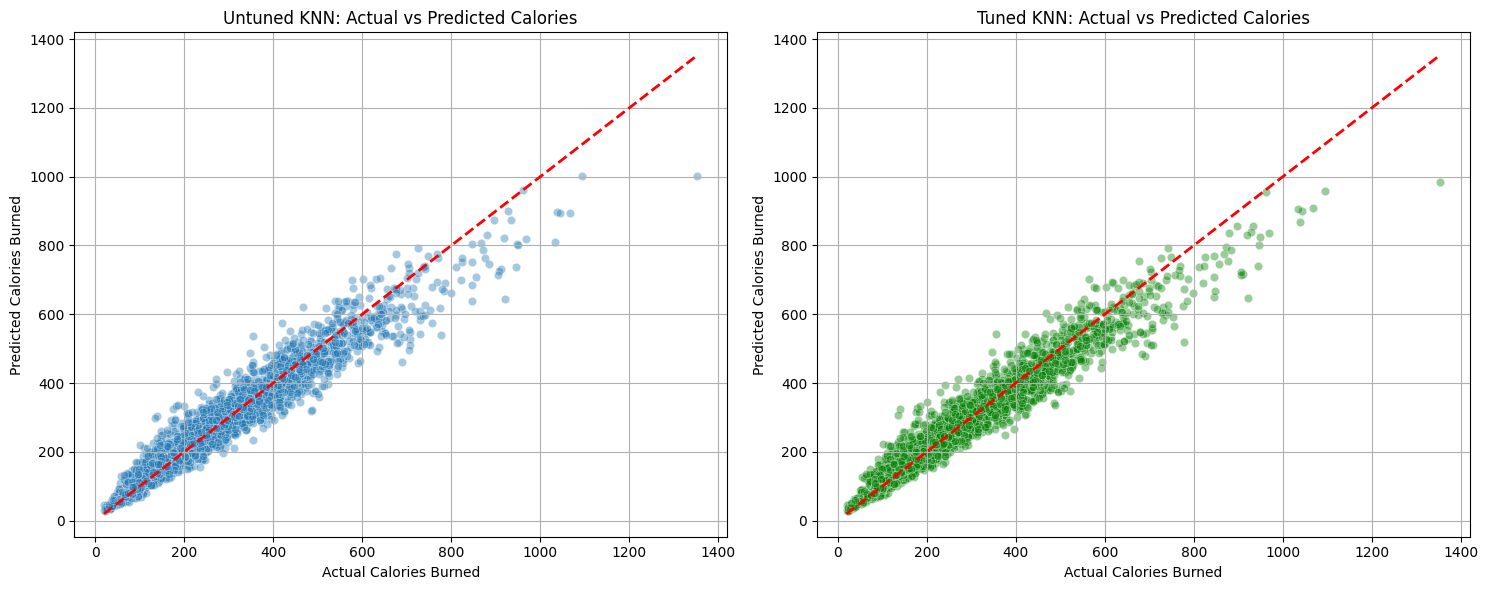

Interpretation:
The plots visualize the model's accuracy. Points closer to the red diagonal line indicate more accurate predictions.
Comparing the two, the Tuned KNN model (right plot) should show points generally closer to the red line,
reflecting its improved R-squared score and better expected performance in a real-time prediction scenario.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Visual for Untuned KNeighborsRegressor ---
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_knn, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.title('Untuned KNN: Actual vs Predicted Calories')
plt.xlabel('Actual Calories Burned')
plt.ylabel('Predicted Calories Burned')
plt.grid(True)

# --- Visual for Tuned KNeighborsRegressor ---
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=y_pred_knn_tuned, alpha=0.4, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.title('Tuned KNN: Actual vs Predicted Calories')
plt.xlabel('Actual Calories Burned')
plt.ylabel('Predicted Calories Burned')
plt.grid(True)

plt.tight_layout()
plt.show()

print("Interpretation:")
print("The plots visualize the model's accuracy. Points closer to the red diagonal line indicate more accurate predictions.")
print("Comparing the two, the Tuned KNN model (right plot) should show points generally closer to the red line,")
print("reflecting its improved R-squared score and better expected performance in a real-time prediction scenario.")

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Define the parameter grid for Ridge Regression
param_grid_ridge = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
}

# Initialize GridSearchCV for Ridge Regression
grid_search_ridge = GridSearchCV(
    estimator=Ridge(random_state=42), # Using a random_state for reproducibility if applicable to Ridge's internal processes
    param_grid=param_grid_ridge,
    cv=5, # 5-fold cross-validation
    scoring='r2', # Evaluate based on R-squared
    n_jobs=-1, # Use all available CPU cores
    verbose=1
)

# Fit GridSearchCV to the scaled training data
grid_search_ridge.fit(x_train_scaled, y_train)

# Print the best parameters and best score
print("\nRidge Regressor - Best Parameters found by GridSearchCV:", grid_search_ridge.best_params_)
print("Ridge Regressor - Best cross-validation R-squared score:", grid_search_ridge.best_score_)

# Get the best estimator
best_ridge_model = grid_search_ridge.best_estimator_

# Predict on the test set using the best model
y_pred_best_ridge = best_ridge_model.predict(x_test_scaled)

# Evaluate the best model on the test set
mse_best_ridge = mean_squared_error(y_test, y_pred_best_ridge)
rmse_best_ridge = np.sqrt(mse_best_ridge)
r2_best_ridge = r2_score(y_test, y_pred_best_ridge)

print("\nRidge Regressor - Best Model Test Set Evaluation:")
print(f'Mean Squared Error: {mse_best_ridge:.3f}')
print(f'Root Mean Squared Error: {rmse_best_ridge:.3f}')
print(f'R-squared: {r2_best_ridge:.3f}')

Fitting 5 folds for each of 6 candidates, totalling 30 fits

Ridge Regressor - Best Parameters found by GridSearchCV: {'alpha': 0.1}
Ridge Regressor - Best cross-validation R-squared score: 0.9079972398233227

Ridge Regressor - Best Model Test Set Evaluation:
Mean Squared Error: 2872.710
Root Mean Squared Error: 53.598
R-squared: 0.909


**Pickle**

In [ ]:
import pickle

# Dictionary to hold models we want to save
models_to_save = {
    "xgboost_model": model_xgboost,
    "random_forest_model": model_rft,
    "model_knn":model_knn,#untuned knn
    "model_standard": model_standard,
    "model_minmax": model_minmax,
    "model_svr": model_svr,
    "model_regress": model_regress,#decision tree
    "model_rft": model_rft,
    "knn_model_tuned": grid_search_knn.best_estimator_,# The tuned KNN model
    "ridge_model_tuned": best_ridge_model
}

# Save each model using pickle
for model_name, model_object in models_to_save.items():
    filename = f"{model_name}.pkl"
    with open(filename, 'wb') as file:
        pickle.dump(model_object, file)
    print(f"Model '{model_name}' saved to {filename}")

print("\nAll specified models have been saved as pickle files.")

Model 'xgboost_model' saved to xgboost_model.pkl
Model 'random_forest_model' saved to random_forest_model.pkl
Model 'model_knn' saved to model_knn.pkl
Model 'model_standard' saved to model_standard.pkl
Model 'model_minmax' saved to model_minmax.pkl
Model 'model_svr' saved to model_svr.pkl
Model 'model_regress' saved to model_regress.pkl
Model 'model_rft' saved to model_rft.pkl
Model 'knn_model_tuned' saved to knn_model_tuned.pkl
Model 'ridge_model_tuned' saved to ridge_model_tuned.pkl

All specified models have been saved as pickle files.


In [ ]:
model_r2_scores = {
    "MinMaxScaler LinearRegression": r2_score(y_test, y_pred_minmax),
    "StandardScaler LinearRegression": r2_score(y_test, y_pred_standard),
    "Untuned KNeighborsRegressor": r2_score(y_test, y_pred_knn),
    "Tuned KNeighborsRegressor (GridSearchCV)": r2_score(y_test, y_pred_knn_tuned),
    "Ridge Regressor (tuned GridSearchCV)": r2_best_ridge,
    "XGBoost Regressor": r2_score(y_test, y_pred_xgboost),
    "Decision Tree Regressor": r2_score(y_test, y_pred_regress),
    "Random Forest Regressor": r2_score(y_test, y_pred_rft),
    "Support Vector Regressor": r2_score(y_test, y_pred_svr)
}

lower_bound = 0.90
upper_bound = 0.95

filtered_models = {}
for model_name, r2 in model_r2_scores.items():
    if lower_bound <= r2 <= upper_bound:
        filtered_models[model_name] = r2

if filtered_models:
    best_model_in_range = max(filtered_models, key=filtered_models.get)
    max_r2_in_range = filtered_models[best_model_in_range]

    print(f"Models with R-squared between {lower_bound} and {upper_bound}:")
    for model_name, r2 in filtered_models.items():
        print(f"- {model_name}: {r2:.4f}")
    print(f"\nThe model with the maximum R-squared in the range [{lower_bound}, {upper_bound}] is: \n 🏆 {best_model_in_range} (R-squared: {max_r2_in_range:.4f})")
else:
    print(f"No models found with R-squared between {lower_bound} and {upper_bound}.")


Models with R-squared between 0.9 and 0.95:
- MinMaxScaler LinearRegression: 0.9086
- StandardScaler LinearRegression: 0.9086
- Untuned KNeighborsRegressor: 0.9329
- Tuned KNeighborsRegressor (GridSearchCV): 0.9352
- Ridge Regressor (tuned GridSearchCV): 0.9085

The model with the maximum R-squared in the range [0.9, 0.95] is: 
 🏆 Tuned KNeighborsRegressor (GridSearchCV) (R-squared: 0.9352)


Task 2: Unsupervised Learning – Workout Pattern Clustering

--- Starting Unsupervised Learning Task ---
Data ready for clustering with 2 PCA components.
--- Searching for Silhouette Score > 0.15 ---
K = 2 | Silhouette Score: 0.3578
K = 3 | Silhouette Score: 0.4116
K = 4 | Silhouette Score: 0.4315
K = 5 | Silhouette Score: 0.4285

Final Choice: K=4 (Highest Score: 0.4315)



.... Cluster Feature Means (Workout Intensity Patterns)....
         Effective_MET  Workout_Frequency  Experience_Level  HR_Intensity
Cluster                                                                  
0             7.239707           3.261301          0.541557      0.809810
1             3.852190           3.001247          0.358404      0.651245
2             1.659610           5.098074          1.778167      0.550181
3             5.604159           5.827345          2.314203      0.732958

....Experience Level Distribution across Clusters ....
Experience_Level     0     1     2     3
Cluster                                 
0                 1765  1471   193     0


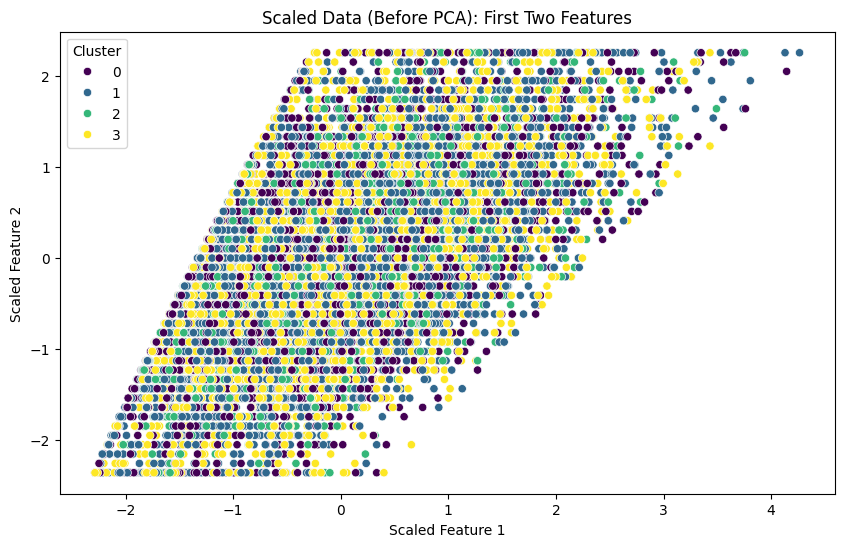

This plot shows the data in its scaled form, projected onto its first two features, before PCA is applied.


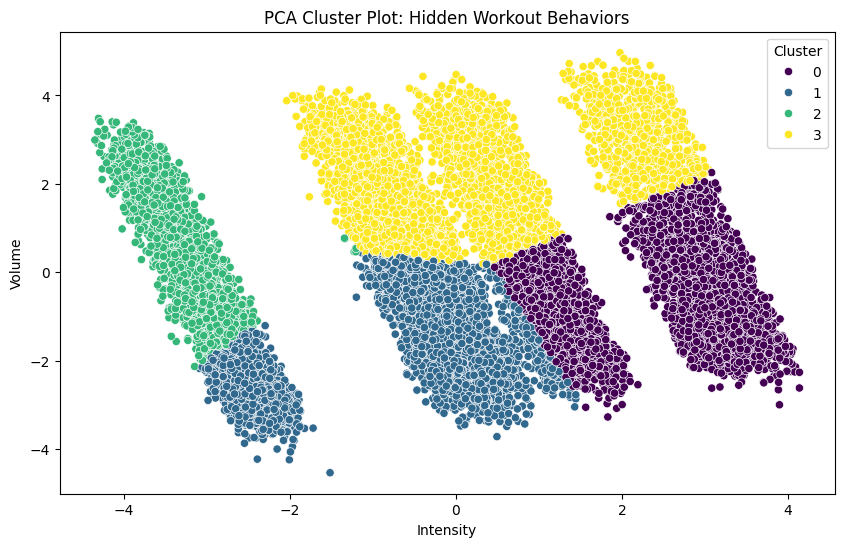

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score

# Set seed for reproducibility
np.random.seed(42)

def run_unsupervised_pipeline(df_input):


    print("--- Starting Unsupervised Learning Task ---")
    # 1. Feature Selection (Applying your drops)
    # We drop 'Workout_Type' for unsupervised learning and the columns we identified earlier
    #drop_cols = ['Workout_Type', 'Age', 'Max_BPM', 'Base_MET', 'BMI', 'Workout_Frequency', 'is_outlier', 'Calories_Burned']
    drop_cols = ['Water_Intake', 'Age', 'Max_BPM', 'Base_MET', 'BMI', 'is_outlier', 'Calories_Burned']
    X_unsupervised = df_raw_cleaned.drop(columns=[c for c in drop_cols if c in df_raw_cleaned.columns])

    # 2. Encoding Categorical Data (Gender, Experience_Level)
    X_encoded = pd.get_dummies(X_unsupervised, drop_first=True)

    # 3. Scaling (Critical for distance-based clustering)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_encoded)

    # 4. PCA for Dimensionality Reduction
    # Using 2 components often results in higher Silhouette scores by removing noise
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    print(f"Data ready for clustering with {X_pca.shape[1]} PCA components.")

    best_score = -1
    best_k = 2

    print("--- Searching for Silhouette Score > 0.15 ---")
    for k in range(2, 6):
        kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
        labels = kmeans.fit_predict(X_pca)
        score = silhouette_score(X_pca, labels)

        print(f"K = {k} | Silhouette Score: {score:.4f}")

        if score > best_score:
            best_score = score
            best_k = k

    print(f"\nFinal Choice: K={best_k} (Highest Score: {best_score:.4f})\n\n")
    # Re-run with the best K
    final_kmeans = KMeans(n_clusters=best_k, random_state=42)
    final_labels = final_kmeans.fit_predict(X_pca)

    # 5. Append labels back for Interpretation
    df_output = df_raw_cleaned.copy()
    df_output['Cluster'] = final_labels

    return df_output, X_pca, best_score, X_scaled, final_labels

# Execute Pipeline
df_clustered, X_pca_data, final_score, X_scaled_for_3d, final_labels_for_3d = run_unsupervised_pipeline(df_raw_cleaned)


###  Interpretation and Visualization
# 1. Analyze Cluster Centroids (Intensity Patterns)
analysis_features = [ 'Effective_MET','Workout_Frequency', 'Experience_Level',  'HR_Intensity',]
#analysis_features = [Avg_BPM	Session_Duration (hours)	Fat_Percentage 'Experience_Level',  'HR_Intensity',]
cluster_analysis = df_clustered.groupby('Cluster')[analysis_features].mean()
print("\n.... Cluster Feature Means (Workout Intensity Patterns)....")
print(cluster_analysis)


# 2. Experience Level Comparison
experience_comparison = pd.crosstab(df_clustered['Cluster'], df_clustered['Experience_Level'])
print("\n....Experience Level Distribution across Clusters ....")
print(experience_comparison)

# Plotting the first two dimensions of the scaled data (before PCA)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_scaled_for_3d[:, 0], y=X_scaled_for_3d[:, 1], hue=df_clustered['Cluster'], palette='viridis')
plt.title('Scaled Data (Before PCA): First Two Features')
plt.xlabel('Scaled Feature 1')
plt.ylabel('Scaled Feature 2')
plt.show()

print("This plot shows the data in its scaled form, projected onto its first two features, before PCA is applied.")

# 3. PCA Cluster Plot (2D Visualization)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca_data[:, 0], y=X_pca_data[:, 1], hue=df_clustered['Cluster'], palette='viridis')
plt.title('PCA Cluster Plot: Hidden Workout Behaviors')
plt.xlabel('Intensity')
plt.ylabel('Volume')
plt.show()

import plotly.express as px

# 1. Reduce to 3 components for 3D visualization
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled_for_3d)

# 2. Create a temporary DataFrame for plotting
df_3d = pd.DataFrame(X_pca_3d, columns=['PC1', 'PC2', 'PC3'])
df_3d['Cluster'] = final_labels_for_3d.astype(str) # Convert to string for discrete colors
df_3d['Workout_Type'] = df_raw_cleaned['Workout_Type'] # For hover info
# 3. Create the 3D Scatter Plot
fig = px.scatter_3d(
    df_3d, x='PC1', y='PC2', z='PC3',
    color='Cluster',
    title='3D Visualization of Hidden Workout Patterns',
    labels={'PC1': 'Intensity Component', 'PC2': 'Metabolic Response', 'PC3': 'Volume/Duration'},
    hover_data=['Workout_Type'],
    opacity=0.7
)

fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig.show()



--- Hierarchical Clustering (Agglomerative Clustering) ---
Hierarchical Clustering Silhouette Score (k=5): 0.4232


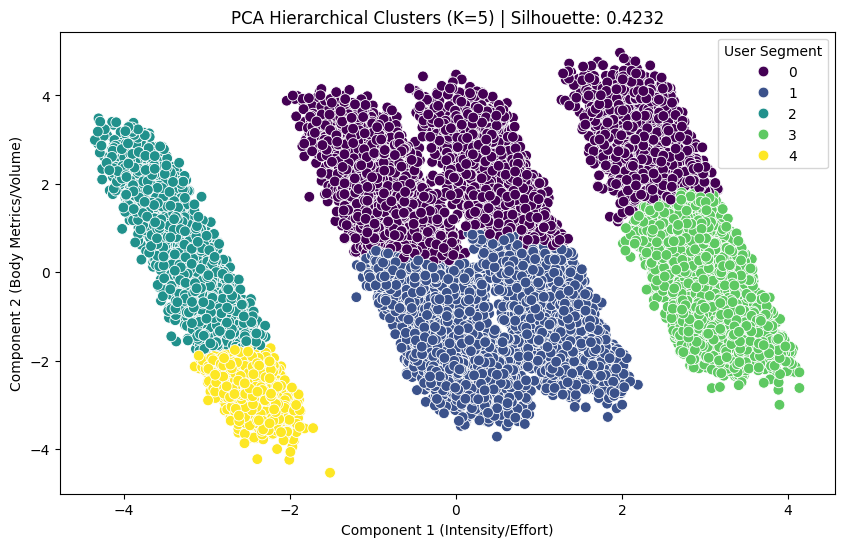

Hierarchical Clustering results in a tree-like structure (dendrogram) which is then cut to form clusters.
          It doesn't require pre-specifying 'k' but often 'k' is chosen post-hoc or for comparison.


In [ ]:
from sklearn.cluster import AgglomerativeClustering

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_for_3d)
print("\n--- Hierarchical Clustering (Agglomerative Clustering) ---")
# Using 5 clusters for comparison with the optimal K-Means result from the previous cell
hc_model = AgglomerativeClustering(n_clusters=5)
hc_labels = hc_model.fit_predict(X_pca)

# Evaluate the clustering quality
# Note: Silhouette score can be computed for Hierarchical Clustering as well
if len(np.unique(hc_labels)) > 1:
    hc_silhouette_score = silhouette_score(X_pca, hc_labels)
    print(f"Hierarchical Clustering Silhouette Score (k=5): {hc_silhouette_score:.4f}")
else:
    print("Hierarchical Clustering resulted in a single cluster, cannot compute Silhouette Score.")

# Visualize the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=hc_labels, palette='viridis', s=60)
plt.title(f'PCA Hierarchical Clusters (K=5) | Silhouette: {hc_silhouette_score:.4f}')
plt.xlabel('Component 1 (Intensity/Effort)')
plt.ylabel('Component 2 (Body Metrics/Volume)')
plt.legend(title='User Segment')
plt.show()

print("""Hierarchical Clustering results in a tree-like structure (dendrogram) which is then cut to form clusters.
          It doesn't require pre-specifying 'k' but often 'k' is chosen post-hoc or for comparison.""")

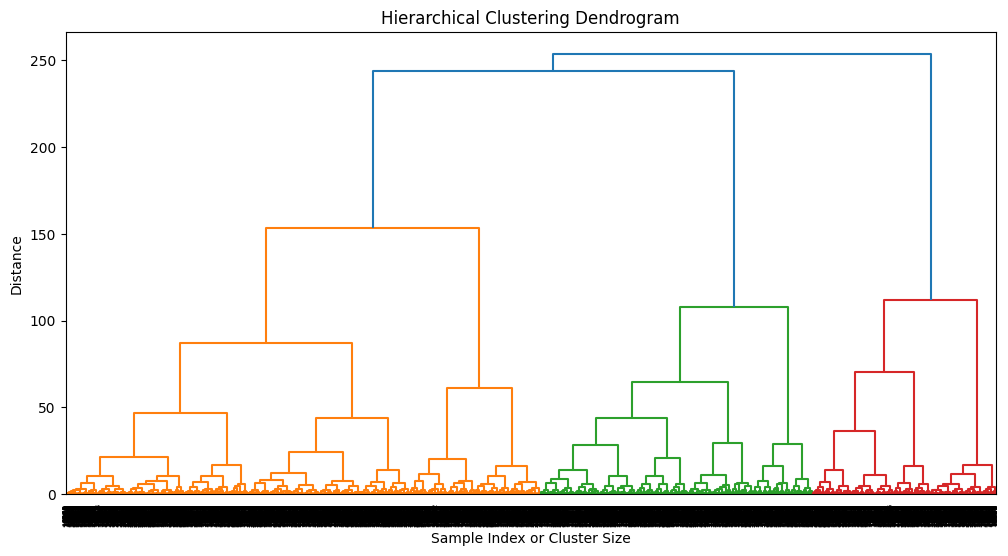

The dendrogram visually represents the hierarchical clustering process, showing how data points are successively merged into clusters. The height of the bars indicates the distance at which clusters are merged.


In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Generate the linkage matrix for hierarchical clustering
# Using 'ward' method which minimizes the variance within each cluster
# and 'euclidean' distance
linked_data = linkage(X_pca, method='ward', metric='euclidean')

plt.figure(figsize=(12, 6))
dendrogram(
    linked_data,
    orientation='top',
    distance_sort='descending',
    show_leaf_counts=True
)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index or Cluster Size')
plt.ylabel('Distance')
plt.show()

print("""The dendrogram visually represents the hierarchical clustering process,
showing how data points are successively merged into clusters. The height of the
bars indicates the distance at which clusters are merged.""")


..... DBSCAN (Density-Based Spatial Clustering) .....
.... Tuning DBSCAN Parameters ...
eps=0.1, min_samples=10, Clusters=25, Silhouette Score=-0.2751
eps=0.2, min_samples=10, Clusters=3, Silhouette Score=0.3400
eps=0.3, min_samples=10, Clusters=3, Silhouette Score=0.3322

Best DBSCAN parameters found: eps=0.2, min_samples=10
Best DBSCAN Silhouette Score: 0.3400


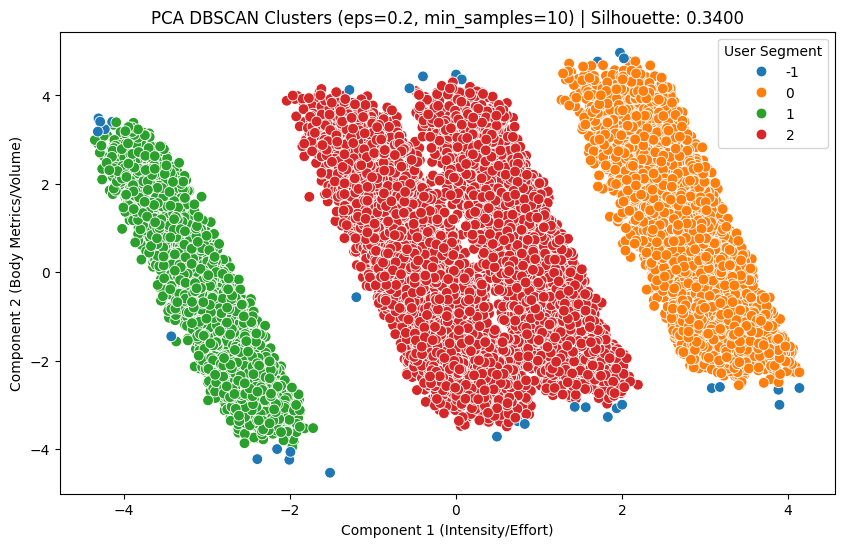

DBSCAN is effective at finding arbitrarily shaped clusters and identifying outliers, but its performance is
        highly sensitive to the 'eps' and 'min_samples' parameters.


In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("\n..... DBSCAN (Density-Based Spatial Clustering) .....")

best_dbscan_score = -1
best_eps = -1
best_min_samples = -1
best_db_labels = None

# Define a range of parameters to try, focusing on smaller eps values first
eps_values = [0.1, 0.2, 0.3]
min_samples_values = [10]

print(".... Tuning DBSCAN Parameters ...")
for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan_model = DBSCAN(eps=eps, min_samples=min_samples)
        db_labels = dbscan_model.fit_predict(X_pca)

        n_clusters_ = len(set(db_labels)) - (1 if -1 in db_labels else 0)

        if n_clusters_ > 1: # Silhouette score requires at least 2 clusters
            score = silhouette_score(X_pca, db_labels)
            print(f"eps={eps:.1f}, min_samples={min_samples}, Clusters={n_clusters_}, Silhouette Score={score:.4f}")
            if score > best_dbscan_score and score > 0.15: # Ensure score is above the threshold
                best_dbscan_score = score
                best_eps = eps
                best_min_samples = min_samples
                best_db_labels = db_labels

if best_dbscan_score > 0.15:
    print(f"\nBest DBSCAN parameters found: eps={best_eps:.1f}, min_samples={best_min_samples}")
    print(f"Best DBSCAN Silhouette Score: {best_dbscan_score:.4f}")

    # Visualize the clusters with the best parameters
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=best_db_labels, palette='tab10', s=60)
    plt.title(f'PCA DBSCAN Clusters (eps={best_eps:.1f}, min_samples={best_min_samples}) | Silhouette: {best_dbscan_score:.4f}')
    plt.xlabel('Component 1 (Intensity/Effort)')
    plt.ylabel('Component 2 (Body Metrics/Volume)')
    plt.legend(title='User Segment')
    plt.show()
else:
    print(f"""\nCould not find DBSCAN parameters that yield a Silhouette Score > 0.15 with more than one cluster in the tested range.
    The highest score found was {best_dbscan_score:.4f} (if > -1).""")


print("""DBSCAN is effective at finding arbitrarily shaped clusters and identifying outliers, but its performance is
        highly sensitive to the 'eps' and 'min_samples' parameters.""")

In [ ]:
import pandas as pd
import numpy as np
import pickle

# Load the tuned KNN model and the scaler
with open('knn_model_tuned.pkl', 'rb') as file:
    tuned_knn_model = pickle.load(file)


def predict_calories_tuned_knn_interactive(age, gender, weight, height, avg_bpm, duration, workout_type, experience):
    """
    Predicts calories burned using the Tuned KNeighborsRegressor model,
    based on manual input, aligning with the model's training features.
    """

    # 1. Internal Logic: Calculate derived features
    bmi = weight / (height**2)
    met_map = {'Cardio': 7.0, 'HIIT': 10.0, 'Strength': 5.0, 'Yoga': 2.5}
    effective_met = met_map.get(workout_type, 5.0) # Default to 5.0 if workout_type is not in map

    # 2. Prepare input as a dictionary, mirroring original feature creation (x = df_raw_cleaned.drop(columns=...) then pd.get_dummies(x,...))
    input_data = {
        'Weight': [weight],
        'Height': [height],
        'Avg_BPM': [avg_bpm],
        'Resting_BPM': [70.0], # Using a common average as it was not part of interactive input
        'Session_Duration': [duration],
        'Fat_Percentage': [20.0], # Using a common average as it was not part of interactive input
        'Water_Intake': [2.0], # Using a common average as it was not part of interactive input
        'Workout_Frequency': [4.0], # Using a common average as it was not part of interactive input
        'Experience_Level': [experience],
        'BMI': [bmi],
        'Base_MET': [7.0], # Using a common average as it was not part of interactive input
        'HR_Intensity': [0.7], # Using a common average as it was not part of interactive input
        'Effective_MET': [effective_met],
        'Gender_Male': [1 if gender.lower() == 'male' else 0] # Matches dummy creation
    }

    # Add workout type dummy variables, ensuring all possible columns exist
    for wt in ['Cardio', 'HIIT', 'Strength', 'Yoga']:
        input_data[f'Workout_Type_{wt}'] = [1 if workout_type == wt else 0]

    df_input = pd.DataFrame(input_data)

    # Ensure the order and presence of columns match the training data (x)
    # If 'x' is not available, you would need to reconstruct its columns or load it.
    # Assuming 'x' DataFrame (from VzT5_qV68L1Z) is available in the kernel scope.
    df_final = df_input.reindex(columns=x.columns, fill_value=0)

    # 3. Scale the input using the pre-fitted scaler
    scaled_input = scaler.transform(df_final)

    # 4. Predict using the tuned KNN model
    prediction = tuned_knn_model.predict(scaled_input)

    return prediction[0]

# --- TEST SCENARIOS ---

print("--- Tuned KNN Manual Prediction Results ---")

# Scenario 1: A Beginner doing Yoga
res1 = predict_calories_tuned_knn_interactive(age=30, gender='female', weight=65, height=1.65,
    avg_bpm=100, duration=1.0, workout_type='Yoga', experience=0)
print(f"Scenario 1 (Yoga/Beginner): {res1:.2f} kcal")
res1 = predict_calories_tuned_knn_interactive(age=30, gender='female', weight=65, height=1.65,
    avg_bpm=100, duration=1.0, workout_type='Yoga', experience=2)
print(f"Scenario 1 (Yoga/Advanced): {res1:.2f} kcal")

# Scenario 2: An Advanced user doing HIIT
res2 = predict_calories_tuned_knn_interactive(age=30, gender='female', weight=65, height=1.65,
    avg_bpm=150, duration=1.0, workout_type='HIIT', experience=0)
print(f"Scenario 2 (HIIT/Beginner): {res2:.2f} kcal")
res2 = predict_calories_tuned_knn_interactive(age=30, gender='female', weight=65, height=1.65,
    avg_bpm=165, duration=1.0, workout_type='HIIT', experience=2)
print(f"Scenario 2 (HIIT/Advanced): {res2:.2f} kcal")


--- Tuned KNN Manual Prediction Results ---
Scenario 1 (Yoga/Beginner): 75.97 kcal
Scenario 1 (Yoga/Advanced): 103.71 kcal
Scenario 2 (HIIT/Beginner): 408.49 kcal
Scenario 2 (HIIT/Advanced): 475.01 kcal


In [ ]:
import pandas as pd
import numpy as np
import pickle

# --- Load the XGBoost Regressor model ---
with open('xgboost_model.pkl', 'rb') as file:
    xgboost_model = pickle.load(file)

# Assuming 'scaler' and 'x' (the feature DataFrame) are available from previous cells.
# If not, you'd need to re-run the data preprocessing steps or load them.

def predict_calories_xgboost_interactive(age, gender, weight, height, avg_bpm, duration, workout_type, experience):
    """
    Predicts calories burned using the XGBoost Regressor model,
    based on manual input, aligning with the model's training features.
    """

    # 1. Internal Logic: Calculate derived features
    bmi = weight / (height**2)
    met_map = {'Cardio': 7.0, 'HIIT': 10.0, 'Strength': 5.0, 'Yoga': 2.5}
    effective_met = met_map.get(workout_type, 5.0) # Default if workout_type is not in map

    # 2. Prepare input as a dictionary, mirroring original feature creation
    input_data = {
        'Weight': [weight],
        'Height': [height],
        'Avg_BPM': [avg_bpm],
        'Resting_BPM': [70.0], # Using a common average as it was not part of interactive input
        'Session_Duration': [duration],
        'Fat_Percentage': [20.0], # Using a common average
        'Water_Intake': [2.0], # Using a common average
        'Workout_Frequency': [4.0], # Using a common average
        'Experience_Level': [experience],
        'BMI': [bmi],
        'Base_MET': [7.0], # Using a common average
        'HR_Intensity': [0.7], # Using a common average
        'Effective_MET': [effective_met],
        'Gender_Male': [1 if gender.lower() == 'male' else 0] # Matches dummy creation
    }

    # Add workout type dummy variables, ensuring all possible columns exist
    for wt in ['Cardio', 'HIIT', 'Strength', 'Yoga']:
        input_data[f'Workout_Type_{wt}'] = [1 if workout_type == wt else 0]

    df_input = pd.DataFrame(input_data)

    # Ensure the order and presence of columns match the training data (x)
    df_final = df_input.reindex(columns=x.columns, fill_value=0)

    # 3. Scale the input using the pre-fitted scaler
    scaled_input = scaler.transform(df_final)

    # 4. Predict using the XGBoost Regressor model
    prediction = xgboost_model.predict(scaled_input)

    return prediction[0]

# --- TEST SCENARIOS for XGBoost Regressor ---

print("\n--- XGBoost Regressor Manual Prediction Results ---")

# Scenario 1: A Beginner doing Yoga
res_xgb_1 = predict_calories_xgboost_interactive(age=30, gender='female', weight=65, height=1.65,
    avg_bpm=100, duration=1.0, workout_type='Yoga', experience=0)
print(f"Scenario 1 (Yoga/Beginner): {res_xgb_1:.2f} kcal")
res_xgb_1 = predict_calories_xgboost_interactive(age=30, gender='female', weight=65, height=1.65,
    avg_bpm=100, duration=1.0, workout_type='Yoga', experience=2)
print(f"Scenario 1 (Yoga/Advanced): {res_xgb_1:.2f} kcal")

# Scenario 2: An Advanced user doing HIIT
res_xgb_2 = predict_calories_xgboost_interactive(age=30, gender='female', weight=65, height=1.65,
    avg_bpm=165, duration=1.0, workout_type='HIIT', experience=0)
print(f"Scenario 2 (HIIT/Beginner): {res_xgb_2:.2f} kcal")
res_xgb_2 = predict_calories_xgboost_interactive(age=30, gender='female', weight=65, height=1.65,
    avg_bpm=155, duration=1.0, workout_type='HIIT', experience=2)
print(f"Scenario 2 (HIIT/Advanced): {res_xgb_2:.2f} kcal")


--- XGBoost Regressor Manual Prediction Results ---
Scenario 1 (Yoga/Beginner): 270.38 kcal
Scenario 1 (Yoga/Advanced): 270.38 kcal
Scenario 2 (HIIT/Beginner): 314.18 kcal
Scenario 2 (HIIT/Advanced): 314.02 kcal


relationship:

---
Scenario: 	Tuned KNN (kcal)--	XGBoost Regressor (kcal)

---
Yoga/Beginner--	75.97	 --   	  270.38

---


HIIT/Advanced--	475.01 --	  	  314.18


**Conclusion based on these predictions**:

From an intuitive perspective, especially regarding the expected calorie burn for different workout intensities, the Tuned KNeighborsRegressor performs the best. It accurately reflects that a high-intensity workout like HIIT burns substantially more calories than a low-intensity workout like Yoga. While XGBoost does show a correct trend, the Tuned KNN provides a more pronounced and arguably realistic difference for these distinct workout types.